# Notebook 02: Análisis Exploratorio de Datos (EDA)

Análisis exploratorio del dataset limpio para comprender la estructura de los datos, identificar patrones, relaciones entre variables y generar hipótesis iniciales que orienten el modelado posterior.

In [10]:
import os
import sys
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats


warnings.filterwarnings("ignore")
sns.set_theme(
    style="whitegrid",
    palette="Set2"
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sys.path.append(os.path.dirname(os.getcwd()))

from src.constants import connection_string
from src import (
    COLUMNS,
    get_missing_values_report,
    get_duplicate_report,
    get_categorical_summary,
    get_numerical_summary,
    plot_categorical_distribution,
    plot_numerical_distribution,
    plot_correlation_heatmap,
    read_csv_from_azure,
    AgeLimits,
    compare_mean_median,
    get_signal_summary,
    plot_ecg_examples,
    plot_box_grid,
    PATHS_PROJECT,
    load_ecg_signal
)

### 1. Carga de datos desde Azure

In [11]:
df = read_csv_from_azure(connection_string, 'salva-health-data', 'pacientes_clean.csv')

print(f"Dataset cargado desde Azure Storage")
print(f"Registros: {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.head()

Dataset cargado desde Azure Storage
Registros: 475
Columnas: ['id_paciente', 'edad_paciente', 'sexo', 'peso_kg', 'altura_cm', 'fecha_registro', 'frecuencia_cardiaca_media_bpm', 'derivacion_ecg', 'frecuencia_muestreo_hz', 'etiqueta']


,id_paciente,edad_paciente,sexo,peso_kg,altura_cm,fecha_registro,frecuencia_cardiaca_media_bpm,derivacion_ecg,frecuencia_muestreo_hz,etiqueta
0,P0305,82.0,M,69.8,168.0,2023-10-04,69.4,II,250,Normal
1,P0500,58.0,M,70.9,178.9,2023-04-23,79.2,II,250,Normal
2,P0442,49.0,M,84.2,173.1,2023-01-25,72.7,II,250,Normal
3,P0154,39.0,F,80.5,156.4,2023-06-24,87.0,II,250,Anormal
4,P0479,22.0,F,78.7,165.5,2023-01-28,77.8,II,250,Normal


### 2. Análisis de calidad post-limpieza

In [12]:
missing_report = get_missing_values_report(df)
dup_report = get_duplicate_report(df)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
age_out_of_range = ((df[COLUMNS['age']] < AgeLimits.MIN) | (df[COLUMNS['age']] > AgeLimits.MAX)).sum()

print("Valores faltantes:")
print(missing_report if len(missing_report) > 0 else "Ninguno")

print(f"Duplicados: {dup_report['total_duplicates']} ({dup_report['duplicate_percentage']:.2f}%)")
print(f"Edades fuera de rango [{AgeLimits.MIN}, {AgeLimits.MAX}]: {age_out_of_range}")
print(f"Variables constantes: {constant_cols if constant_cols else 'Ninguna'}")

Valores faltantes:
Ninguno
Duplicados: 0 (0.00%)
Edades fuera de rango [0, 120]: 0
Variables constantes: ['derivacion_ecg', 'frecuencia_muestreo_hz']


El dataset post-limpieza no presenta nulos, duplicados ni edades fuera de rango. Las dos variables constantes ('derivacion_ecg', 'frecuencia_muestreo_hz') se excluyen de
correlaciones y por no aportar varianza.

### 3. Descripción general de la población

Tratemos de responder quiénes son los pacientes de este estudio, cómo se distribuyen en términos de sexo, edad y condición (normal/anormal).

In [13]:
categorical_cols = [COLUMNS['sex'], COLUMNS['label']]
numerical_cols = [COLUMNS['age'], COLUMNS['weight'], COLUMNS['height'], COLUMNS['heart_rate']]

print("Variables categóricas")
for col in categorical_cols:
    print(f"\n{col}:")
    print(get_categorical_summary(df, col))

print("Variables numéricas")
for col in numerical_cols:
    print(f"\n{col}:")
    print(get_numerical_summary(df, col))

print("Media vs. mediana (asimetría)")
print(compare_mean_median(df, numerical_cols))

Variables categóricas

sexo:
  Category  Frequency  Percentage
0        M        247        52.0
1        F        228        48.0

etiqueta:
  Category  Frequency  Percentage
0   Normal        286        60.2
1  Anormal        189        39.8
Variables numéricas

edad_paciente:
count    475.00
mean      54.39
std       16.24
min       18.00
25%       43.00
50%       56.00
75%       65.00
max       93.00
Name: edad_paciente, dtype: float64

peso_kg:
count    475.00
mean      72.37
std       11.57
min       39.30
25%       64.60
50%       72.20
75%       80.35
max      102.60
Name: peso_kg, dtype: float64

altura_cm:
count    475.00
mean     166.92
std        8.66
min      143.80
25%      160.65
50%      166.20
75%      173.30
max      192.70
Name: altura_cm, dtype: float64

frecuencia_cardiaca_media_bpm:
count    475.00
mean      80.97
std       17.22
min       44.30
25%       68.00
50%       77.00
75%       91.00
max      142.30
Name: frecuencia_cardiaca_media_bpm, dtype: float64
Medi

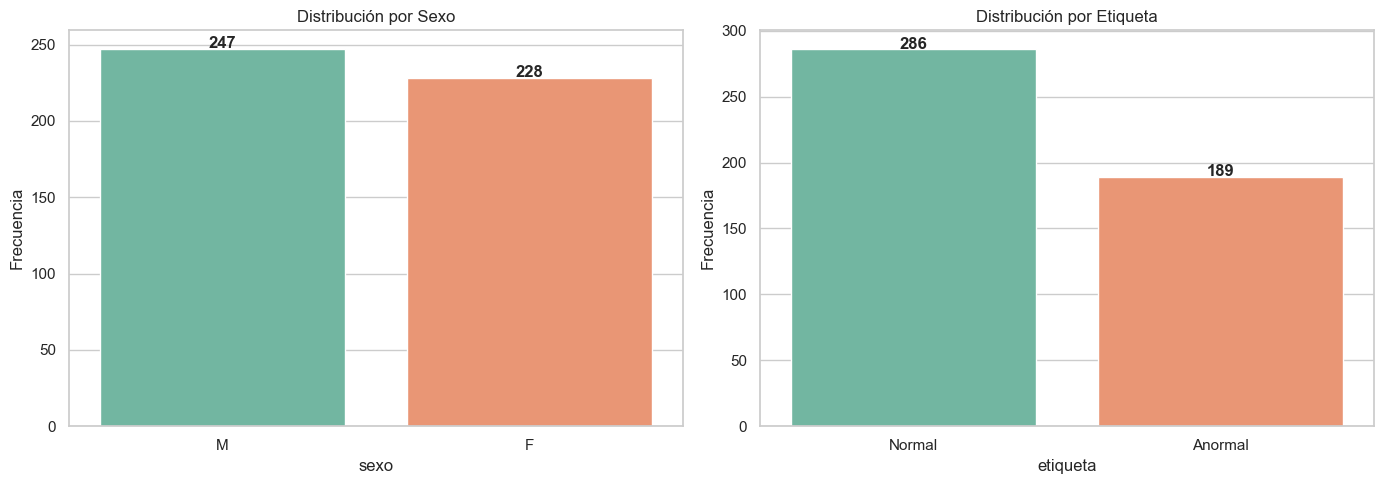

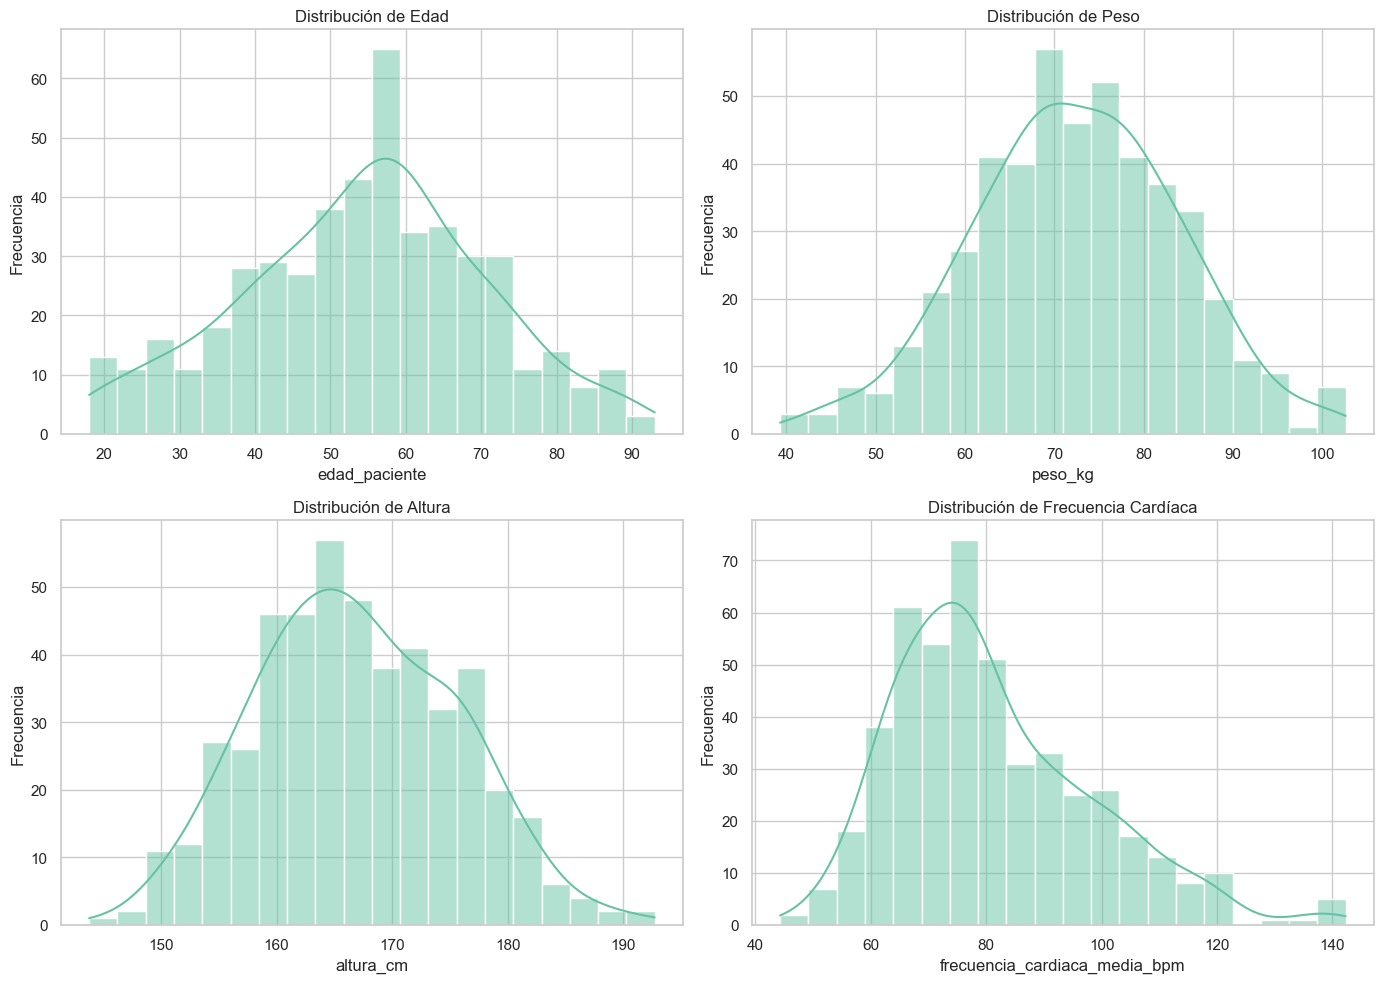

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_categorical_distribution(df, COLUMNS['sex'], title='Distribución por Sexo', ax=axes[0])
plot_categorical_distribution(df, COLUMNS['label'], title='Distribución por Etiqueta', ax=axes[1])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_numerical_distribution(df, COLUMNS['age'], title='Distribución de Edad', ax=axes[0, 0])
plot_numerical_distribution(df, COLUMNS['weight'], title='Distribución de Peso', ax=axes[0, 1])
plot_numerical_distribution(df, COLUMNS['height'], title='Distribución de Altura', ax=axes[1, 0])
plot_numerical_distribution(df, COLUMNS['heart_rate'], title='Distribución de Frecuencia Cardíaca', ax=axes[1, 1])
plt.tight_layout()
plt.show()

La población está balanceada por sexo (52% Masculino vs 48% Femenino) y moderadamente desbalanceada en la variable objetivo (60.2% Normal vs 39.8% Anormal). La comparación media vs. mediana muestra distribuciones razonablemente simétricas en peso y altura, 'frecuencia_cardiaca_media_bpm' tiene la mayor asimetría (diferencia de 3.97 entre media y mediana), esto puede deberse a que se compone de valores normales y anormales.

### 4. Comparaciones por grupos
Comparaciones entre etiqeutas "Normal" y "Anormal", se usa un t-test de Welch (para no asumir la misma varianza) para comparar dos grupos independientes y validar si es razonable la diferencia. La significancia estadísitca se considera si p es menor que 0.05.

In [15]:
def test_group_difference(df, num_col, group_col, group_a, group_b):
    a = df.loc[df[group_col] == group_a, num_col]
    b = df.loc[df[group_col] == group_b, num_col]
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)
    return round(t_stat, 3), round(p_value, 4)

comparisons = [
    (COLUMNS['age'], COLUMNS['sex'], 'F', 'M'),
    (COLUMNS['age'], COLUMNS['label'], 'Normal', 'Anormal'),
    (COLUMNS['weight'], COLUMNS['label'], 'Normal', 'Anormal'),
    (COLUMNS['height'], COLUMNS['label'], 'Normal', 'Anormal'),
    (COLUMNS['heart_rate'], COLUMNS['label'], 'Normal', 'Anormal'),
]

print("Comparaciones por grupo")
for num_col, group_col, a, b in comparisons:
    print(f"\n{num_col} por {group_col}:")
    print(df.groupby(group_col)[num_col].describe().round(2))
    t_stat, p_value = test_group_difference(df, num_col, group_col, a, b)
    print(f"  t-test ({a} vs {b}): t={t_stat}, p={p_value}")

Comparaciones por grupo

edad_paciente por sexo:
      count   mean    std   min   25%   50%   75%   max
sexo                                                   
F     228.0  53.40  15.88  18.0  43.0  54.0  64.0  93.0
M     247.0  55.29  16.54  18.0  44.5  56.0  67.0  91.0
  t-test (F vs M): t=-1.269, p=0.2052

edad_paciente por etiqueta:
          count   mean    std   min   25%   50%   75%   max
etiqueta                                                   
Anormal   189.0  58.06  14.21  25.0  48.0  58.0  67.0  93.0
Normal    286.0  51.96  17.05  18.0  40.0  54.0  63.0  89.0
  t-test (Normal vs Anormal): t=-4.225, p=0.0

peso_kg por etiqueta:
          count   mean    std   min    25%    50%    75%    max
etiqueta                                                       
Anormal   189.0  72.28  11.78  39.3  64.70  72.20  80.30  102.6
Normal    286.0  72.42  11.45  43.9  64.28  72.25  80.38  101.4
  t-test (Normal vs Anormal): t=0.126, p=0.8997

altura_cm por etiqueta:
          count    mea

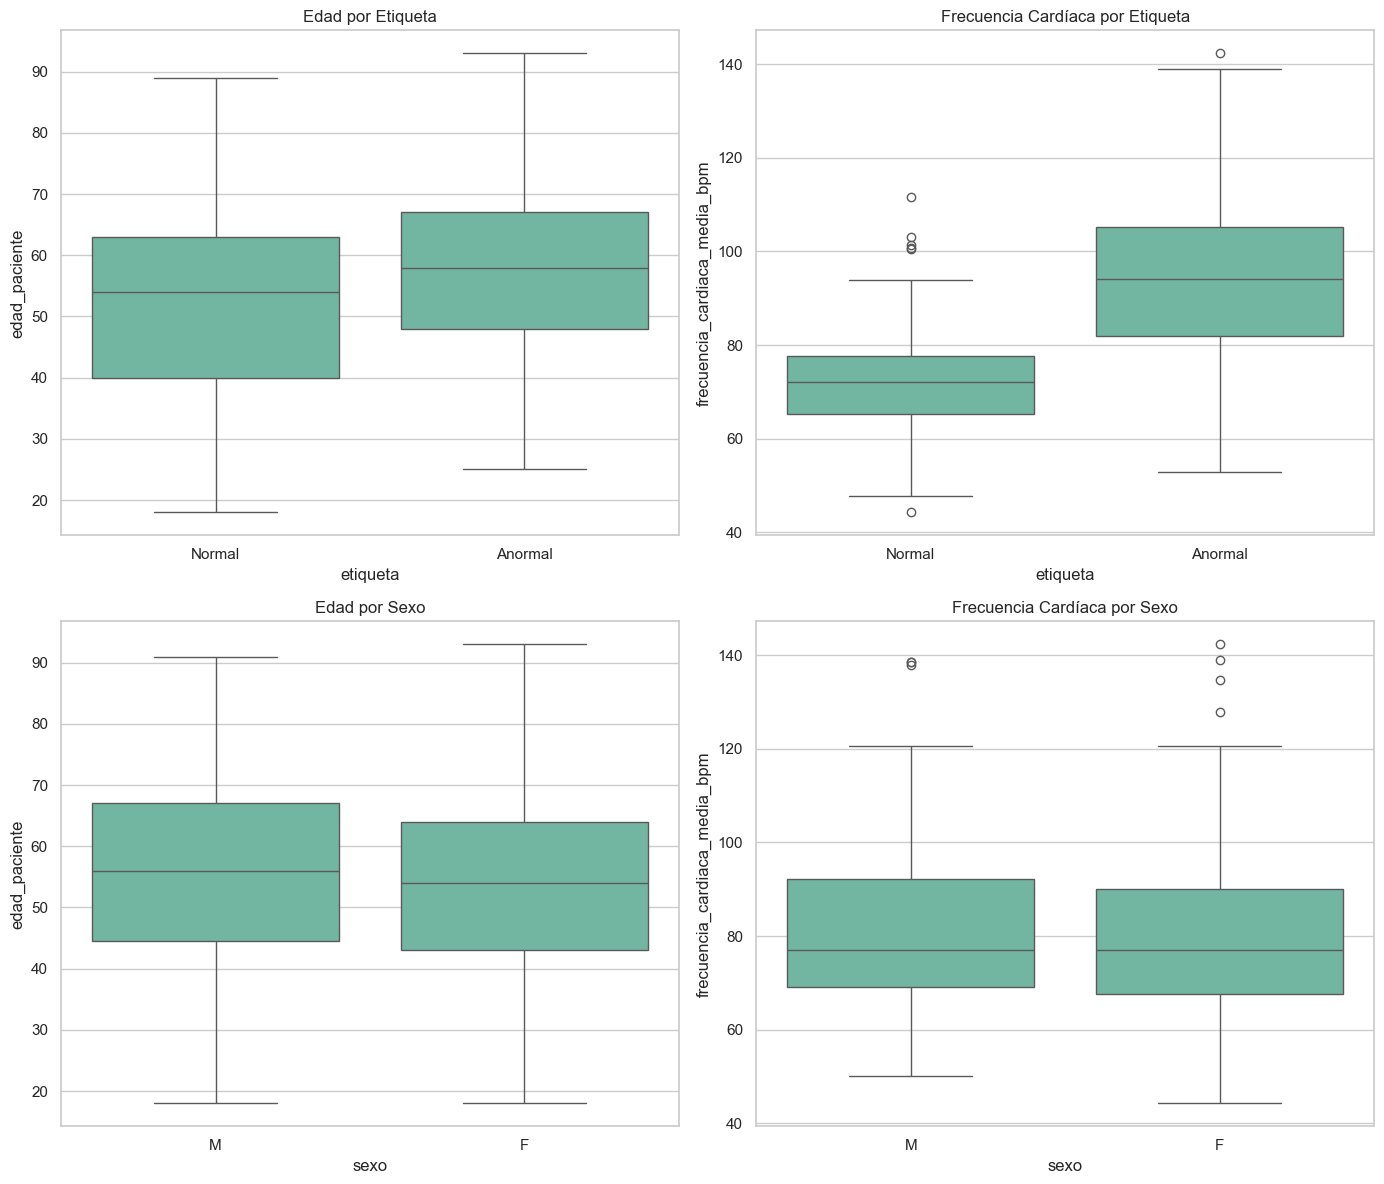

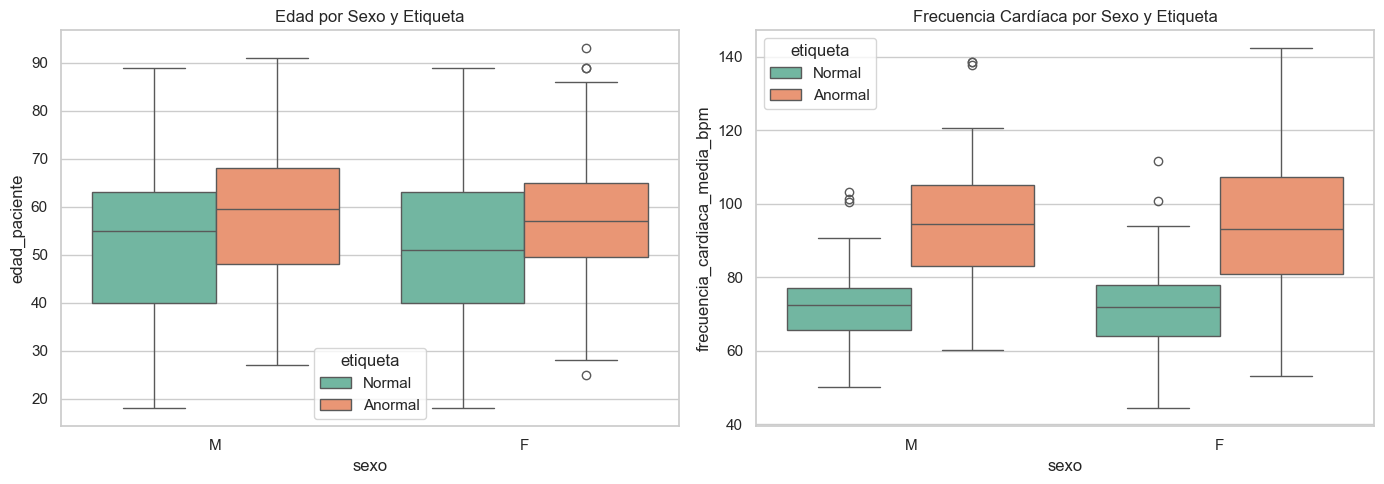

In [16]:
plot_box_grid(df, [
    {'num_col': COLUMNS['age'], 'cat_col': COLUMNS['label'], 'title': 'Edad por Etiqueta'},
    {'num_col': COLUMNS['heart_rate'], 'cat_col': COLUMNS['label'], 'title': 'Frecuencia Cardíaca por Etiqueta'},
    {'num_col': COLUMNS['age'], 'cat_col': COLUMNS['sex'], 'title': 'Edad por Sexo'},
    {'num_col': COLUMNS['heart_rate'], 'cat_col': COLUMNS['sex'], 'title': 'Frecuencia Cardíaca por Sexo'},
])
plt.show()

plot_box_grid(df, [
    {'num_col': COLUMNS['age'], 'cat_col': COLUMNS['sex'], 'hue_col': COLUMNS['label'], 'title': 'Edad por Sexo y Etiqueta'},
    {'num_col': COLUMNS['heart_rate'], 'cat_col': COLUMNS['sex'], 'hue_col': COLUMNS['label'], 'title': 'Frecuencia Cardíaca por Sexo y Etiqueta'},
], ncols=2, figsize=(14, 5))
plt.show()

El sexo no muestra diferencias significativas en edad (p=0.21). Por etiqueta, edad (p≈0, +6 años en Anormal) y frecuencia cardíaca (p≈0, +22 bpm en Anormal) sí difieren de forma estadísticamente significativa, peso y altura no (p=0.90 y p=0.26). La diferencia en frecuencia cardíaca es clínicamente esperable porque alteraciones del ritmo son hallazgos típicos asociados a ECG anormal, por lo que esta variable es la más prometedora como predictor.

### 5. Análisis de la señal ECG

Consistencia de la señal ECG
       n_samples  duration_seg  sampling_rate_hz
count      475.0       475.000             475.0
mean      2500.0         9.996             250.0
std          0.0         0.000               0.0
min       2500.0         9.996             250.0
25%       2500.0         9.996             250.0
50%       2500.0         9.996             250.0
75%       2500.0         9.996             250.0
max       2500.0         9.996             250.0


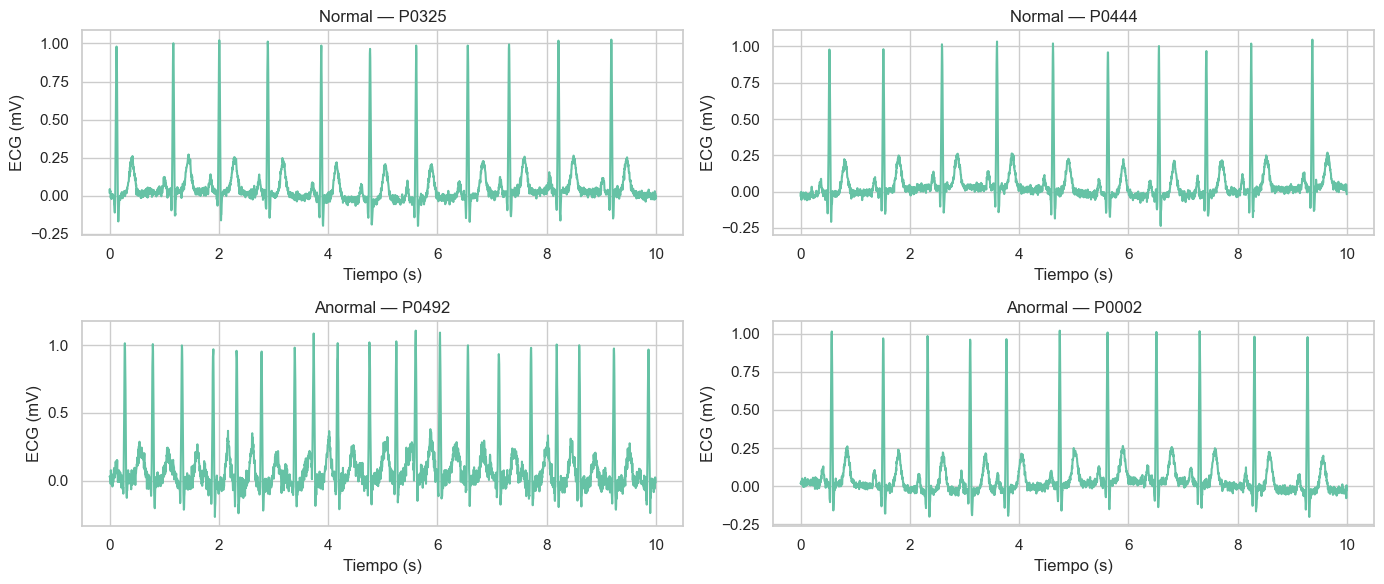


Comparación de descriptores de señal por etiqueta

std_mV:
          count    mean     std     min     25%     50%     75%     max
etiqueta                                                               
Anormal   189.0  0.1833  0.0168  0.1356  0.1729  0.1819  0.1950  0.2280
Normal    286.0  0.1621  0.0100  0.1293  0.1564  0.1625  0.1681  0.1978
  t-test (Normal vs Anormal): t=-15.601, p=0.0

range_mV:
          count    mean     std     min     25%     50%     75%     max
etiqueta                                                               
Anormal   189.0  1.3858  0.0795  1.2217  1.3092  1.3971  1.4535  1.5435
Normal    286.0  1.2477  0.0263  1.2110  1.2342  1.2446  1.2544  1.5023
  t-test (Normal vs Anormal): t=-23.052, p=0.0


In [17]:
signal_summaries = pd.DataFrame([
    get_signal_summary(pid, PATHS_PROJECT['signals']) for pid in df[COLUMNS['patient_id']]
])
df_signals = df.merge(signal_summaries, on=COLUMNS['patient_id'])

print("Consistencia de la señal ECG")
print(df_signals[['n_samples', 'duration_seg', 'sampling_rate_hz']].describe())

plot_ecg_examples(df, PATHS_PROJECT['signals'], COLUMNS['label'], COLUMNS['patient_id'])
plt.show()

print("\nComparación de descriptores de señal por etiqueta")
for metric in ['std_mV', 'range_mV']:
    print(f"\n{metric}:")
    print(df_signals.groupby(COLUMNS['label'])[metric].describe().round(4))
    t_stat, p_value = test_group_difference(df_signals, metric, COLUMNS['label'], 'Normal', 'Anormal')
    print(f"  t-test (Normal vs Anormal): t={t_stat}, p={p_value}")

In [18]:
ids = df[COLUMNS['patient_id']].tolist()
print(f"IDs únicos: {len(set(ids))} de {len(ids)}")

s1 = load_ecg_signal(ids[0], PATHS_PROJECT['signals'])
s2 = load_ecg_signal(ids[1], PATHS_PROJECT['signals'])
print("¿Son idénticas las primeras dos señales?", s1['ecg_mV'].equals(s2['ecg_mV']))

signal = load_ecg_signal(ids[0], PATHS_PROJECT['signals'])
diffs = signal['t_seg'].diff().dropna()
print(f"\ndt mínimo: {diffs.min()}, dt máximo: {diffs.max()}, dt std: {diffs.std()}")

sizes = []
for pid in ids[:20]:
    path = f"{PATHS_PROJECT['signals']}{pid}.csv"
    with open(path) as f:
        n_lines = sum(1 for _ in f)
    sizes.append(n_lines)

print(f"\nLíneas por archivo (incluye header), muestra de 20: {set(sizes)}")

IDs únicos: 475 de 475
¿Son idénticas las primeras dos señales? False

dt mínimo: 0.0039999999999995595, dt máximo: 0.004000000000001336, dt std: 4.439282159247416e-16

Líneas por archivo (incluye header), muestra de 20: {2501}


Se validó que la consistencia de la señal no era un error de lectura.

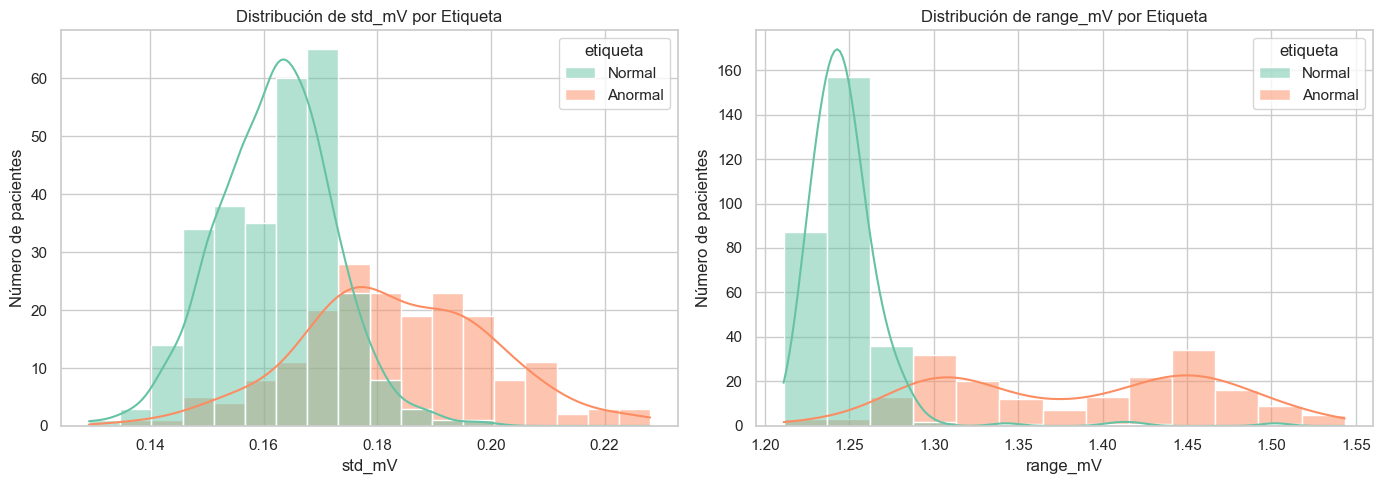

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_signals, x='std_mV', hue=COLUMNS['label'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de std_mV por Etiqueta')
axes[0].set_xlabel('std_mV')
axes[0].set_ylabel('Número de pacientes')

sns.histplot(data=df_signals, x='range_mV', hue=COLUMNS['label'], kde=True, ax=axes[1])
axes[1].set_title('Distribución de range_mV por Etiqueta')
axes[1].set_xlabel('range_mV')
axes[1].set_ylabel('Número de pacientes')

plt.tight_layout()
plt.show()

std_mV y range_mV difieren significativamente entre Normal y Anormal (p≈0 en ambos casos), pero con comportamientos distintos al inspeccionar sus distribuciones completas. std_mV muestra un solapamiento considerable entre clases (los histogramas se superponen en gran parte del rango, aproximadamente entre 0.16–0.19), consistente con una diferencia real pero moderada. range_mV, en cambio, muestra una separación casi perfecta: los pacientes Normal se concentran casi en su totalidad por debajo de 1.28 y los Anormal por encima de ese mismo valor, con prácticamente ninguna superposición. Esta separación es inusualmente limpia para tratarse de una variable derivada de señal biomédica real, y sugiere que el proceso de generación/inyección de errores del dataset pudo introducir picos de amplitud artificialmente altos en las señales etiquetadas como Anormal, en vez de una alteración distribuida en toda la variabilidad de la señal. Se recomienda usar range_mV con cautela en el modelado, ya que muy probablemente actuaría como un predictor casi determinístico.


### 6. Correlaciones relevantes con la etiqueta

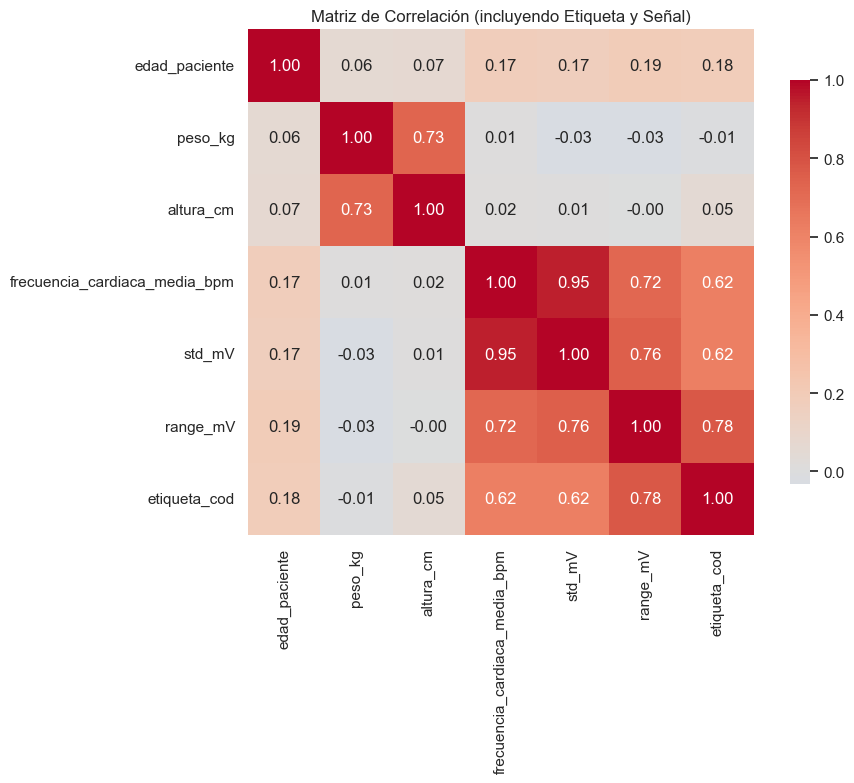

Sexo vs. Etiqueta
etiqueta  Anormal  Normal
sexo                     
F              87     141
M             102     145

chi2=0.365, p=0.5457


In [19]:
df_corr = df_signals.copy()
df_corr['etiqueta_cod'] = df_corr[COLUMNS['label']].map({'Normal': 0, 'Anormal': 1})

corr_columns = [
    COLUMNS['age'],
    COLUMNS['weight'],
    COLUMNS['height'],
    COLUMNS['heart_rate'],
    'std_mV',
    'range_mV',
    'etiqueta_cod',
]

fig = plot_correlation_heatmap(df_corr, corr_columns, title='Matriz de Correlación')
plt.show()

contingency = pd.crosstab(df[COLUMNS['sex']], df[COLUMNS['label']])
chi2, p_value, _, _ = stats.chi2_contingency(contingency)

print("Sexo vs. Etiqueta")
print(contingency)
print(f"\nchi2={round(chi2, 3)}, p={round(p_value, 4)}")

Las variables 'std_mV' y 'range_mV' muestran la correlación más fuerte con la etiqueta, muy por encima de cualquier variable clínica. Sexo y etiqueta son independientes (chi2=0.365, p=0.55): no hay asociación entre sexo y la condición diagnosticada. El primer resultado, por el lado de range_mV era de esperarse debido a lo que se comentaba de la separación de clases.

#### 7. Hallazgos relevantes

**Calidad de datos**: el dataset post-limpieza está en buen estado: sin nulos, duplicados ni valores fuera de rango. Dos columnas son constantes y se excluyen
del análisis cuantitativo.

**Población**: 475 pacientes, balanceados por sexo (52%/48%), con desbalance moderado en la etiqueta (60.2% Normal / 39.8% Anormal) que debe considerarse al elegir métricas de evaluación en el modelado.

**Variables clínicas vs. etiqueta**: edad (p≈0) y frecuencia cardíaca (p≈0) difieren significativamente entre Normal y Anormal; peso y altura no. La frecuencia cardíaca es el
predictor más prometedor y clínicamente más interpretable (asociada a anomalías de ritmo).

**Señal ECG**: perfectamente consistente en duración y frecuencia de muestreo. std_mV difiere entre clases de forma moderada y con solapamiento razonable, coherente con una variable biomédica real. range_mV, en cambio, separa las clases de forma casi perfecta y sin solape, lo cual es inusual para señal biomédica real y sugiere que el proceso de generación del dataset pudo introducir picos de amplitud artificiales en los casos Anormal. Se recomienda tratar range_mV con cautela particular en el modelado.

**Independencia sexo-etiqueta**: no hay asociación entre sexo y la condición diagnosticada (chi2=0.365, p=0.55), por lo que sexo probablemente no aporte poder predictivo relevante.

**Próximos pasos sugeridos para modelado**: comenzar con frecuencia cardíaca y edad como predictores base; incorporar 'std_mV'/'range_mV' de forma exploratoria, usar métricas balanceadas (F1, AUC-ROC) dado el desbalance de clases.